<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        Trabalho em grupo - Modelo SARIMA <span style="color: #00a2ff;"></span>
    </h2>
    <hr style="border: 0; border-top: 1px solid #1e293b; margin: 10px 0;">
    <p">
        <b>Membros:</b> <span style="color: #b6e4fa ; font-size: 12px;">Gabriel Martins Oliveira | Leticia Nascimento da Silva | Theo Correia Martins | Vitor De Mello Maciel  </span> 
    </p>
    <p>
        <b>Matéria:</b> <span style="color: #b6e4fa ; font-size: 12px;">Séries Temporais</span>
    </p>
    <p>
        <b>Data Entrega:</b> <span style="color: #b6e4fa ; font-size: 12px;">22/05/2026</span> 
    </p>
</div>

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
            background-color: #0a0e14; 
            color: #e0e6ed; 
            padding: 30px; 
            border: 1px solid #1e293b; 
            border-radius: 8px;
            line-height: 1.6;">

<div style="border-bottom: 2px solid #0078d4; padding-bottom: 15px; margin-bottom: 20px;">
        <h1 style="color: #00a2ff; margin: 0; font-size: 24px; letter-spacing: 2px; text-transform: uppercase;">
            <span style="color: #ffffff;"></span> Descrição do Projeto
        </h1>
    </div>

<div style="margin-bottom: 25px; background: rgba(0, 120, 212, 0.05); padding: 15px; border-left: 4px solid #0078d4;">
        <p style="margin-bottom: 0;">
            O objetivo deste trabalho é realizar a modelagem completa de uma <b>série temporal não estacionária</b>. Através de técnicas de diferenciação e análise estatística, buscaremos extrair padrões preditivos e validar a eficiência do modelo contra referências de mercado.
        </p>
    </div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin-bottom: 25px;">
        <div style="background: #111827; padding: 15px; border: 1px solid #1e293b; border-radius: 4px;">
            <strong style="color: #00d4ff; display: block; margin-bottom: 10px;"> Implementação Técnicas</strong>
            <ul style="margin: 0; padding-left: 20px; font-size: 14px; color: #94a3b8;">
                <li>Teste de Estacionariedade; </li>
                <li>Contrução de Pipeline Completa; </li>
                <li>Modelagem Comparativa (Base Models).</li>
            </ul>
        </div>
        <div style="background: #111827; padding: 15px; border: 1px solid #1e293b; border-radius: 4px;">
            <strong style="color: #00d4ff; display: block; margin-bottom: 10px;"> Métricas de Validação</strong>
            <ul style="margin: 0; padding-left: 20px; font-size: 14px; color: #94a3b8;">
                <li>MAE (Mean Absolute Error) de Teste</li>
                <li>MAE (Rolling Forecast)</li>
                <li>Análise de Resíduos (Ruído Branco)</li>
            </ul>
        </div>
    </div>

<div style="background: #0f172a; padding: 10px; border-radius: 4px; font-family: monospace; font-size: 13px;">
        <span style="color: #00ff88;">[INFO]</span> Entregáveis: 
        <code style="color: #38bdf8; background: transparent;">Notebook.ipynb</code> & 
        <code style="color: #38bdf8; background: transparent;">Relatorio_Final.pdf</code>
    </div>

</div>

<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        01. Importações <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;">Para deixar o projeto organizado, vamos colocar todas as importações necessárias nesse bloco de código.</span> 
    </p>   
</div>

In [22]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from IPython import display
from IPython.display import display
warnings.filterwarnings('ignore')

# Estatística / Modelagem
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL


# Métricas
from sklearn.metrics import mean_absolute_error


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        02. Funções Pipeline <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;">Para deixar o projeto organizado, vamos colocar todas as funções necessárias nesses blocos de código.</span> 
    </p>   
</div>

In [23]:
def testa_estacionariedade(serie):
    resultado_adf = adfuller(serie.dropna())
    p_adf = resultado_adf[1]
    
    resultado_kpss = kpss(serie.dropna())
    p_kpss = resultado_kpss[1]
    
    print(f'ADF P-Value: {p_adf:.4f} | KPSS P-Value: {p_kpss:.4f}')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_acf(serie.dropna(), lags=40, ax=ax, title="Função de Autocorrelação (ACF)")
    plt.show()
    
    # Estacionária se ADF <= 0.05 e KPSS > 0.05
    if p_adf <= 0.05 and p_kpss > 0.05:
        print("=> A série é ESTACIONÁRIA.")
        return True
    elif p_adf > 0.05 and p_kpss <= 0.05:
        print("=> A série NÃO É ESTACIONÁRIA.")
        return False
    else:
        print("=> Inconclusivo / Estacionária por partes. Assumindo NÃO ESTACIONÁRIA por segurança.")
        return False

def reverte_diferenciacao(previsoes_diff, serie_original_treino, ordem_diff):
    if ordem_diff == 0:
        return previsoes_diff

    if ordem_diff == 1:
        ultimo_valor_real = serie_original_treino.iloc[-1]
        previsoes_escala_original = ultimo_valor_real + previsoes_diff.cumsum()
        return previsoes_escala_original

    elif ordem_diff == 2:
        primeira_diff_treino = serie_original_treino.diff().dropna()
        ultimo_valor_primeira_diff = primeira_diff_treino.iloc[-1]
        
        previsoes_1a_diff = ultimo_valor_primeira_diff + previsoes_diff.cumsum()
        
        ultimo_valor_real = serie_original_treino.iloc[-1]
        previsoes_escala_original = ultimo_valor_real + previsoes_1a_diff.cumsum()
        return previsoes_escala_original        

def torna_estacionaria(serie, nome="Série"):
    print(f"\n--- Analisando: {nome} ---")
    plt.plot(serie.values, color='blue')
    plt.title(f'Série Original - {nome}')
    plt.show()
    
    serie_diff = serie.copy()
    ordem = 0
    
    while not testa_estacionariedade(serie_diff) and ordem < 2:
        serie_diff = serie_diff.diff().dropna()
        ordem += 1
        print(f"\nx Aplicada diferenciação de ordem {ordem}")
        
        plt.plot(serie_diff.values, color='green')
        plt.title(f'Série Diferenciada (Ordem {ordem}) - {nome}')
        plt.show()
        
    return serie_diff, ordem


In [24]:
def melhor_m_stl(serie, max_m):
    serie = serie.dropna()
    melhor_m = None
    melhor_forca = -np.inf
    resultados = []

    for m_candidate in range(2, max_m + 1):
        stl_result = STL(serie, period=m_candidate, robust=True).fit()
        denom = np.var(stl_result.seasonal + stl_result.resid)
        if denom == 0:
            forca = 0.0
        else:
            forca = 1 - (np.var(stl_result.resid) / denom)

        resultados.append((m_candidate, forca))

        if forca > melhor_forca:
            melhor_forca = forca
            melhor_m = m_candidate

    print("Avaliação de candidatos:")
    for m_candidate, forca in resultados:
        print(f"m = {m_candidate:2d} -> Força de sazonalidade: {forca:.4f}")

    print(f"\nMelhor m escolhido: {melhor_m} (força de sazonalidade = {melhor_forca:.4f})")

    stl_best = STL(serie, period=melhor_m, robust=True).fit()
    fig = stl_best.plot()
    fig.set_size_inches(20, 10)
    plt.tight_layout()
    plt.show()

    print(f"Força de sazonalidade (0-1): {melhor_forca: .4f}")
    return melhor_m

In [25]:
def testa_sarima(order, seasonal_order, y):
   model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False)
   model_fit = model.fit(disp=False, maxiter=100)
   return model_fit

def busca_melhor_sarima(y, p_range, d_range, q_range, P_range, D_range, Q_range, m_range):
   resultados = []
   melhor_bic = float('inf')
   melhor_ordem = None
   melhor_seasonal = None
   melhor_modelo = None

   for p in p_range:
      for d in d_range:
         for q in q_range:
            for P in P_range:
               for D in D_range:
                  for Q in Q_range:
                     for m in m_range:
                         ordem = (p, d, q)
                         seasonal_ordem = (P, D, Q, m)
                         try:
                            resultado = testa_sarima(ordem, seasonal_ordem, y)
                            bic = float(resultado.bic)
                            resultados.append({
                               'order': ordem,
                               'seasonal_order': seasonal_ordem,
                               'bic': bic
                            })
       
                            if bic < melhor_bic:
                               melhor_bic = bic
                               melhor_ordem = ordem
                               melhor_seasonal = seasonal_ordem
                               melhor_modelo = resultado
                         except Exception:
                            pass

   tabela = pd.DataFrame(resultados)
   tabela = tabela.sort_values('bic').reset_index(drop=True)
   print(f"Melhor por BIC: {melhor_ordem} x {melhor_seasonal} | BIC = {melhor_bic:.2f}")
   return tabela, melhor_modelo, melhor_ordem, melhor_seasonal

def plota_previsoes(treino, teste, previsoes, titulo="Previsões"):
    plt.figure(figsize=(14, 6))
    plt.plot(treino.index, treino, label='Treino', color='blue')
    plt.plot(teste.index, teste, label='Teste (Real)', color='green')
    plt.plot(previsoes.index, previsoes, label='Previsão', color='red', linestyle='--')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def diagnostica_residuos(modelo, ordem, sazonal_ordem, lags=20):
    residuos = modelo.resid
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(residuos)
    axes[0].set_title("Resíduos do Modelo")
    plot_acf(residuos, lags=lags, ax=axes[1], title="ACF dos Resíduos")
    plt.show()
    
    df_lb = acorr_ljungbox(residuos, lags=[lags], return_df=True)
    p_value = df_lb['lb_pvalue'].values[0]
    
    print(f"Teste Ljung-Box (lag={lags}) p-value: {p_value:.4f}")
    if p_value > 0.05:
         print("Resíduos parecem ruído branco (Não há autocorrelação significativa).")
    else:
         print("Resíduos NÃO são ruído branco (Ainda há padrões não capturados).")
         
    return df_lb

def rolling_forecast_sarima(serie, split_index, order, seasonal_order, step=4):
    historico = list(serie.iloc[:split_index])
    teste = serie.iloc[split_index:]
    previsoes = []
    
    for t in range(0, len(teste), step):
        atual = historico[-len(historico):]
        modelo = SARIMAX(atual, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
        modelo_fit = modelo.fit(disp=False)
        yhat = modelo_fit.forecast(steps=step)
        previsoes.extend(yhat)
        
        historico.extend(teste.iloc[t:t+step])
        
    return pd.Series(previsoes[:len(teste)], index=teste.index)



<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        03. Carregamento e Entendimento da Base <span style="color: #00a2ff;"></span>
    </h2>
    <p>
        <span style="color: #b6e4fa ; font-size: 16px;">Carregar a base de dados do S&P 500, realizar a agregação semanal e verificar a consistência dos dados.</span> 
    </p>   
</div>


In [26]:
df = pd.read_csv('naoEstacionaria\\vendas_sazonal.csv')

COLUNA_DATA = 'data'
COLUNA_VALOR = 'vendas'

# Limpeza e conversão
# df = df.drop(columns=['Open', 'Low', 'Close', 'Volume'], errors='ignore')
df[COLUNA_DATA] = pd.to_datetime(df[COLUNA_DATA])
df = df.sort_values(COLUNA_DATA)
df.set_index(COLUNA_DATA, inplace=True)

# Agrupamos semanalmente pela média do valor Vendas para reduzir o ruído
df_weekly = df[[COLUNA_VALOR]].resample('W').mean()

nulos = df_weekly.isnull().sum()
print("Valores nulos por coluna na base semanal:")
print(nulos)

if nulos.sum() > 0:
    df_weekly = df_weekly.interpolate(method='linear')
    print("x Valores nulos preenchidos via interpolação linear.")

display(df_weekly.head())
print("\nEstatísticas descritivas da base semanal:")
display(df_weekly.describe())

print("\n--- 4.1 Apresentação da Base ---")
print("Origem: Base de Vendas Sazonais")
print("Contexto: Série temporal para modelagem.")
print(f"Variável Temporal: {COLUNA_DATA}")
print(f"Variável Analisada: {COLUNA_VALOR}")
print("Frequência: Semanal")
print(f"Período: de {df_weekly.index[0].date()} a {df_weekly.index[-1].date()}")
print(f"Quantidade de observações: {len(df_weekly)}")
print("Possíveis problemas: Presença de nulos resolvidos por interpolação linear.")


Valores nulos por coluna na base semanal:
vendas    0
dtype: int64


,vendas
data,
2024-01-07,113.633264
2024-01-14,105.532278
2024-01-21,116.687490
2024-01-28,102.613953
2024-02-04,101.323908



Estatísticas descritivas da base semanal:


,vendas
count,105.000000
mean,100.105423
std,11.693322
min,77.391066
25%,90.043301
50%,100.036673
75%,110.187628
max,122.417010



--- 4.1 Apresentação da Base ---
Origem: Base de Vendas Sazonais
Contexto: Série temporal para modelagem.
Variável Temporal: data
Variável Analisada: vendas
Frequência: Semanal
Período: de 2024-01-07 a 2026-01-04
Quantidade de observações: 105
Possíveis problemas: Presença de nulos resolvidos por interpolação linear.


<div style="
    background-color: #0a0e14; 
    color: #00a2ff; 
    padding: 20px; 
    border-left: 5px solid #0078d4; 
    border-radius: 5px; 
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">
    <h2 style="color: #ffffff; margin: 0; text-transform: uppercase; letter-spacing: 2px;">
        04. Análise de Estacionaridade <span style="color: #00a2ff;"></span>
    </h2>
    <p">
        <span style="color: #b6e4fa ; font-size: 16px;"> Após o carregamento das bases, vamos entender comportamento e em qual classficação ela se encaixa.</span> 
    </p>
    <p>
        <span style=" color: #00a2ff"> Estácionária</span>
    </p>
    <p>
        <span style=" color: #00a2ff"> Não Estácionária</span>
    </p>
</div>

### Análise Visual e Decomposição STL

Plota o gráfico temporal da série semanal e realiza a decomposição STL com o período sazonal de 52 semanas.


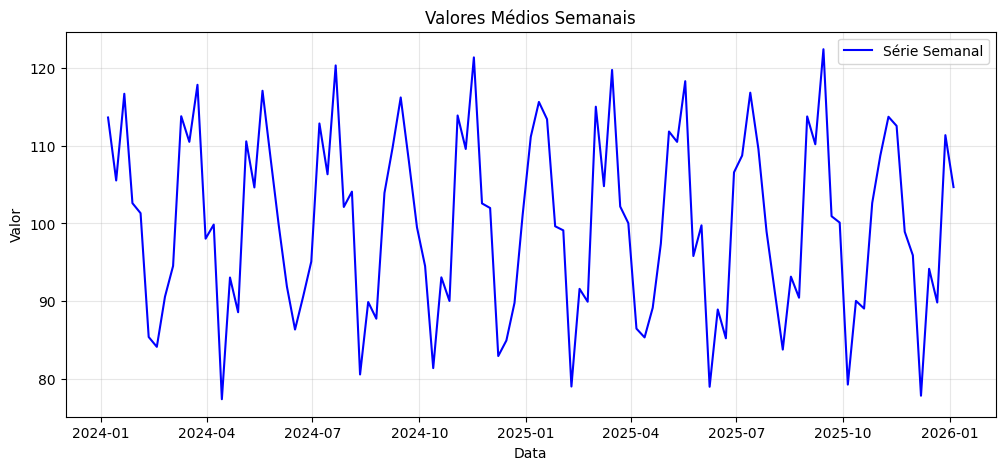

Avaliação de candidatos:
m =  2 -> Força de sazonalidade: 0.8376
m =  3 -> Força de sazonalidade: -0.2587
m =  4 -> Força de sazonalidade: 0.3117
m =  5 -> Força de sazonalidade: -0.0159
m =  6 -> Força de sazonalidade: 0.0744
m =  7 -> Força de sazonalidade: 0.4475
m =  8 -> Força de sazonalidade: 0.8171
m =  9 -> Força de sazonalidade: 0.9052
m = 10 -> Força de sazonalidade: 0.5005
m = 11 -> Força de sazonalidade: 0.1761
m = 12 -> Força de sazonalidade: 0.0050
m = 13 -> Força de sazonalidade: 0.1734
m = 14 -> Força de sazonalidade: 0.0374
m = 15 -> Força de sazonalidade: 0.3304
m = 16 -> Força de sazonalidade: 0.6231
m = 17 -> Força de sazonalidade: 0.9817
m = 18 -> Força de sazonalidade: 0.7879
m = 19 -> Força de sazonalidade: 0.5815
m = 20 -> Força de sazonalidade: 0.1657
m = 21 -> Força de sazonalidade: -0.1553
m = 22 -> Força de sazonalidade: -0.0591
m = 23 -> Força de sazonalidade: 0.2461
m = 24 -> Força de sazonalidade: 0.7036
m = 25 -> Força de sazonalidade: 0.8329
m = 26 -> F

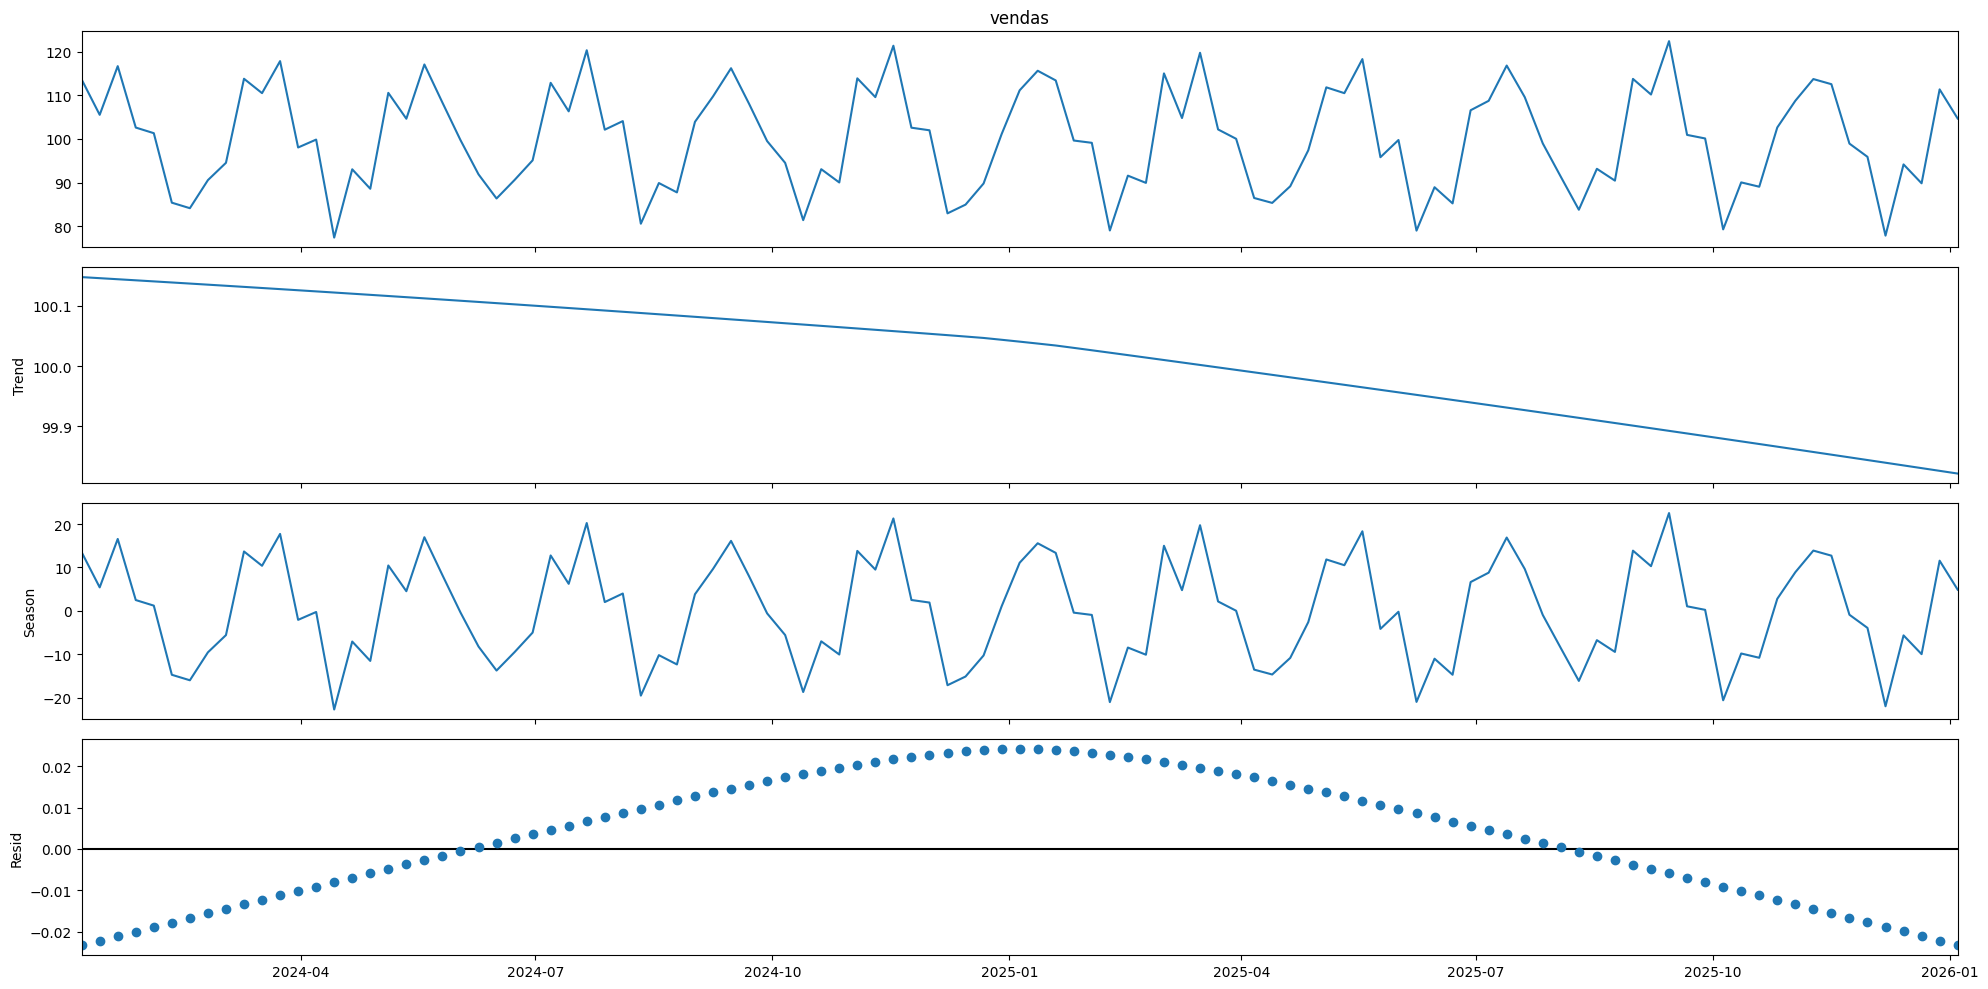

Força de sazonalidade (0-1):  1.0000


In [27]:
# Plot da série temporal semanal
plt.figure(figsize=(12, 5))
plt.plot(df_weekly.index, df_weekly[COLUNA_VALOR].values, color='blue', label='Série Semanal')
plt.title('Valores Médios Semanais')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Encontrando o melhor M para o STL e plotando
melhor_m = melhor_m_stl(df_weekly[COLUNA_VALOR], max_m=70)
m_sugerido_stl = melhor_m



### Análise Visual da Série

**Interpretação (Alunos):**
- Comportamento geral:
- Tendência:
- Sazonalidade:
- Períodos de crescimento/queda:
- Mudanças estruturais:


### Interpretação da Decomposição STL

**Interpretação (Alunos):**
- O que os componentes de série observada, tendência, sazonalidade e resíduo demonstram após a decomposição com o m sugerido?


### Cálculo da Força da Sazonalidade

Calcula numericamente as métricas de força da sazonalidade e da tendência com base nos resíduos do STL.


### Força da Sazonalidade

**Interpretação (Alunos):**
- Baseado no valor numérico retornado pelo `melhor_m_stl`, interprete a força da sazonalidade.
- Como isso influencia a escolha de modelos sazonais (SARIMA)?


### Testes de Estacionariedade (ADF & KPSS)

Executa os testes ADF e KPSS na série semanal original para determinar o grau de diferenciação necessário para torná-la estacionária.


--- Diagnóstico de Estacionariedade da Série Original ---

--- Analisando: Série Semanal ---


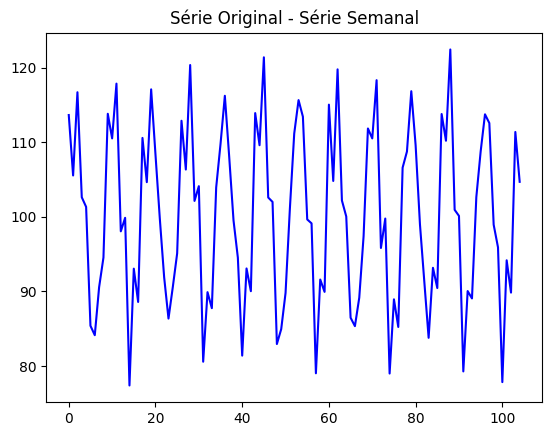

ADF P-Value: 0.0275 | KPSS P-Value: 0.1000


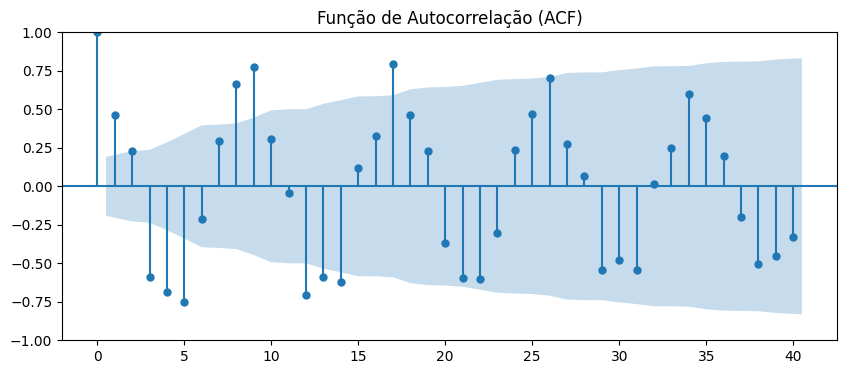

=> A série é ESTACIONÁRIA.

Ordem de diferenciação (d) final sugerida: 0


In [28]:
print("--- Diagnóstico de Estacionariedade da Série Original ---")
# testa_estacionariedade(df_weekly[COLUNA_VALOR])

serie_diff, ordem_diff = torna_estacionaria(df_weekly[COLUNA_VALOR], nome="Série Semanal")
print(f"\nOrdem de diferenciação (d) final sugerida: {ordem_diff}")


### Interpretação da Estacionariedade

**Interpretação (Alunos):**
- A série original é estacionária?
- Há evidências de tendência?
- Há necessidade de diferenciação comum ou sazonal?
- Os testes ADF e KPSS apontam conclusões compatíveis ou conflitantes?


### Análise de ACF e PACF da Série Diferenciada

Gera as autocorrelações lineares para apoiar a seleção inicial de parâmetros p, q, P, Q.


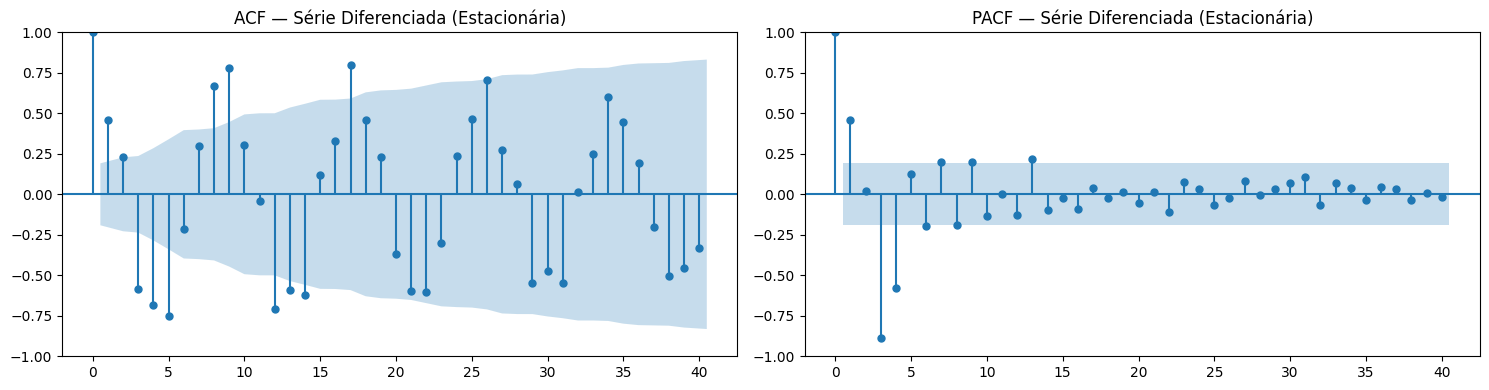

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(serie_diff, lags=40, ax=axes[0], title="ACF — Série Diferenciada (Estacionária)")
plot_pacf(serie_diff, lags=40, ax=axes[1], title="PACF — Série Diferenciada (Estacionária)")
plt.tight_layout()
plt.show()


### Análise ACF e PACF

**Interpretação (Alunos):**
- A partir dos gráficos, quais seriam as ordens iniciais recomendadas para p, d, q, D?


### Divisão Cronológica entre Treino e Teste

Divide os dados mantendo a ordenação temporal (80% para treino e 20% para teste).


In [30]:
# Divisão temporal (80/20)
train_size = int(len(df_weekly) * 0.8)
treino = df_weekly[COLUNA_VALOR].iloc[:train_size]
teste = df_weekly[COLUNA_VALOR].iloc[train_size:]

print(f"Total de observações: {len(df_weekly)}")
print(f"Treino: {len(treino)} semanas (de {treino.index[0].date()} a {treino.index[-1].date()})")
print(f"Teste: {len(teste)} semanas (de {teste.index[0].date()} a {teste.index[-1].date()})")


Total de observações: 105
Treino: 84 semanas (de 2024-01-07 a 2025-08-10)
Teste: 21 semanas (de 2025-08-17 a 2026-01-04)


### Justificativa Treino/Teste

**Interpretação (Alunos):**
- Justifique a escolha de 80/20 para o conjunto de teste.


### Modelagem de Referência (Base Models)

Calcula previsões simples (Média, Naive, Drift e Seasonal Naive) sobre o conjunto de teste para benchmarking.


*(Área reservada para o grupo implementar as importações ou funções e chamadas dos Base Models - Naive, Drift, SMA, etc)*

In [31]:
# INSERIR CÓDIGO DOS BASE MODELS AQUI


### Treinamento e Otimização do Modelo SARIMA

Executa busca em grade (Grid Search) no conjunto de treino, obtém o melhor modelo por menor BIC e gera as previsões estáticas de teste.


Iniciando Grid Search do SARIMA... Isso pode demorar devido ao teste de múltiplos 'm'.
Melhor por BIC: (1, 0, 1) x (1, 0, 0, 52) | BIC = 221.96

--- Resumo Estatístico do Melhor Modelo SARIMA ---
                                      SARIMAX Results                                      
Dep. Variable:                              vendas   No. Observations:                   84
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 52)   Log Likelihood                -104.110
Date:                             Fri, 22 May 2026   AIC                            216.220
Time:                                     11:30:44   BIC                            221.956
Sample:                                 01-07-2024   HQIC                           218.090
                                      - 08-10-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025  

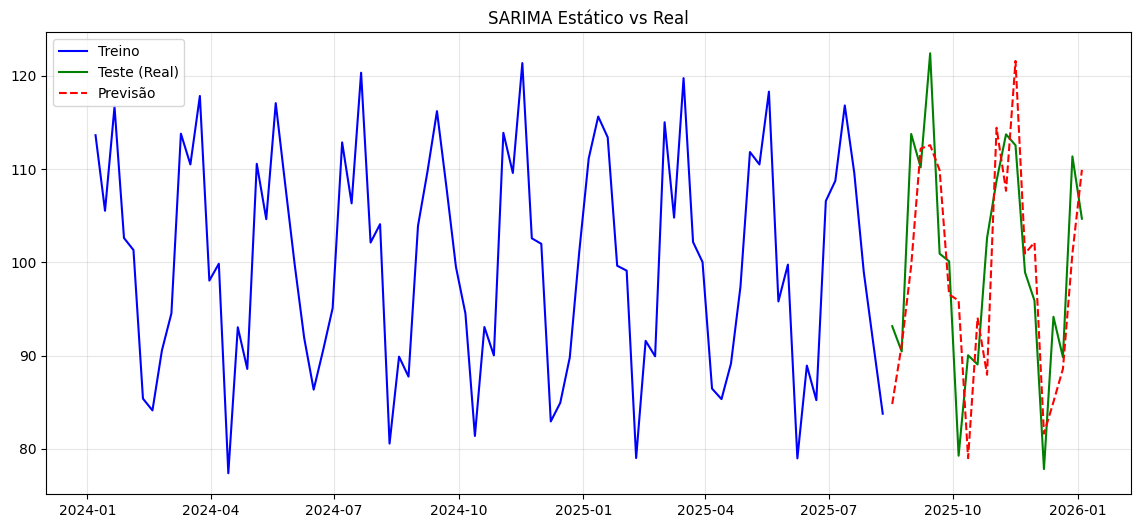

In [ ]:
p_range = range(0, 2)     # AR
d_range = [ordem_diff]    # Diferenciação
q_range = range(0, 2)     # MA
P_range = range(0, 2)     # AR Sazonal
D_range = [0]             # Diferenciação Sazonal
Q_range = range(0, 2)     # MA Sazonal


m_range = list(set([m_sugerido_stl, 4, 52]))

print("Iniciando Grid Search do SARIMA... Isso pode demorar devido ao teste de múltiplos 'm'.")
tabela_bic, melhor_modelo, melhor_ordem, melhor_seasonal = busca_melhor_sarima(
    treino, p_range, d_range, q_range, P_range, D_range, Q_range, m_range
)

print("\n--- Resumo Estatístico do Melhor Modelo SARIMA ---")
print(melhor_modelo.summary())

previsoes_sarima = melhor_modelo.forecast(steps=len(teste))
previsoes_sarima = pd.Series(previsoes_sarima, index=teste.index)

previsoes_sarima_treino = melhor_modelo.predict(start=treino.index[0], end=treino.index[-1])

plota_previsoes(treino, teste, previsoes_sarima, titulo="SARIMA Estático vs Real")



### Definição dos parâmetros SARIMA

**Interpretação (Alunos):**
- Justifique os parâmetros encontrados do SARIMA.
- Explique por que o `m` escolhido pelo modelo pode diferir do indicado pelo STL.


### Diagnóstico dos Resíduos do SARIMA

Executa o diagnóstico gráfico e estatístico dos resíduos, aplicando o teste de Ljung-Box com ajuste correto de graus de liberdade.


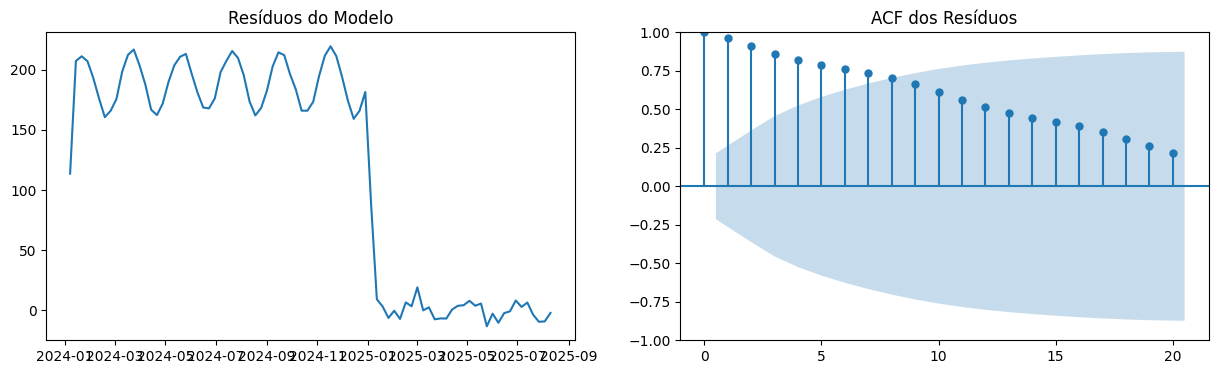

Teste Ljung-Box (lag=20) p-value: 0.0000
Resíduos NÃO são ruído branco (Ainda há padrões não capturados).


In [33]:
resultado_lb = diagnostica_residuos(melhor_modelo, melhor_ordem, melhor_seasonal, lags=20)


### Diagnóstico dos Resíduos

**Interpretação (Alunos):**
- Os resíduos parecem ruído branco?
- Ainda existe autocorrelação significativa?
- O modelo capturou bem a estrutura temporal da série?
- Há sinais de que o modelo pode ser melhorado?


### Previsão com Rolling Forecast (Janela Móvel)

Executa a estratégia de Rolling Forecast sobre o teste reajustando os parâmetros mensalmente (step=4) e atualizando o modelo dinamicamente.


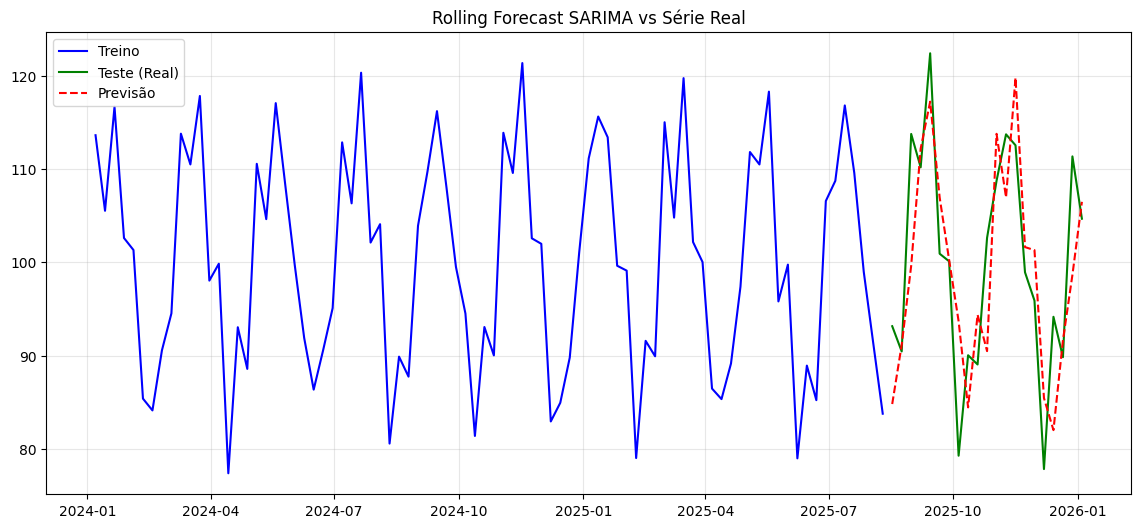

In [34]:
previsoes_rolling = rolling_forecast_sarima(
    df_weekly[COLUNA_VALOR], 
    split_index=train_size, 
    order=melhor_ordem, 
    seasonal_order=melhor_seasonal, 
    step=4
)

plota_previsoes(treino, teste, previsoes_rolling, titulo="Rolling Forecast SARIMA vs Série Real")


### Rolling Forecast

**Interpretação (Alunos):**
- O rolling forecast melhorou o desempenho?
- O modelo se beneficiou da atualização com novos dados?
- Esse comportamento faz sentido para a série analisada?


### 13. Comparação das Métricas de Erro (MAE)

Compila o erro absoluto médio (MAE) de teste para todos os modelos estudados em uma tabela comparativa.


In [35]:
print("--- Comparação de Métricas (MAE) ---")

mae_sarima_treino = mean_absolute_error(treino, previsoes_sarima_treino)
mae_sarima_teste = mean_absolute_error(teste, previsoes_sarima)
mae_rolling_teste = mean_absolute_error(teste, previsoes_rolling)

print(f"MAE SARIMA (Treino): {mae_sarima_treino:.2f}")
print(f"MAE SARIMA Estático (Teste): {mae_sarima_teste:.2f}")
print(f"MAE SARIMA Rolling Forecast (Teste): {mae_rolling_teste:.2f}")

print("\n*(Alunos: Adicionem os MAEs dos Base Models aqui)*")



--- Comparação de Métricas (MAE) ---
MAE SARIMA (Treino): 119.49
MAE SARIMA Estático (Teste): 7.32
MAE SARIMA Rolling Forecast (Teste): 6.54

*(Alunos: Adicionem os MAEs dos Base Models aqui)*
